# Plot the best results
This script will create all the figures (comparison, times series etc), based on the best combination of parameters and auxiliary variables.

In [27]:
using Pkg
Pkg.activate("../")
include("../scripts/CopepodsNN.jl")
include("../scripts/CopepodsNNplots.jl")
include("../scripts/param.jl")
using NCDatasets
using Dates
using Glob
using DIVAnd
using GeoDatasets
using Makie
using CairoMakie
using GeoMakie
using Statistics
doplot = true
coastline = GeoMakie.coastlines(10);
using JupyterFormatter
enable_autoformat()

  Activating project at `~/Projects/EMODnet/EMODnet-Biology/EMODnet-Biology-Interpolation-NN-Copepods`


2-element Vector{Function}:
 format_current_cell (generic function with 1 method)
 format_current_cell (generic function with 1 method)

## Files and directories

In [5]:
varname = "Small_copepods"
# varname = "Large_copepods"

"Small_copepods"

### Results files

In [11]:
bestfilelist = [
    "$(varname)_best.nc",
    "$(varname)_best_bathy.nc",
    "$(varname)_best_sst.nc",
    "$(varname)_best_coast.nc",
    "$(varname)_best_bathy_sst.nc",
    "$(varname)_best_bathy_sst_coast.nc",
]

6-element Vector{String}:
 "Small_copepods_best.nc"
 "Small_copepods_best_bathy.nc"
 "Small_copepods_best_sst.nc"
 "Small_copepods_best_coast.nc"
 "Small_copepods_best_bathy_sst.nc"
 "Small_copepods_best_bathy_sst_coast.nc"

In [38]:
vmin = Dict("Small_copepods" => 0.0, "Large_copepods" => 0.0)
vmax = Dict("Small_copepods" => 0.5, "Large_copepods" => 50.0)

Dict{String, Float64} with 2 entries:
  "Large_copepods" => 50.0
  "Small_copepods" => 0.5

## Read all the observations

In [13]:
rawdatafile = joinpath(dataprocdir, "$(varname)_DINCAE_$(regionname).nc")
obslon, obslat, obsdates, obsvalues, obsid, _ = CopepodsNN.read_data_nc(rawdatafile, domain);

## Plot the loss

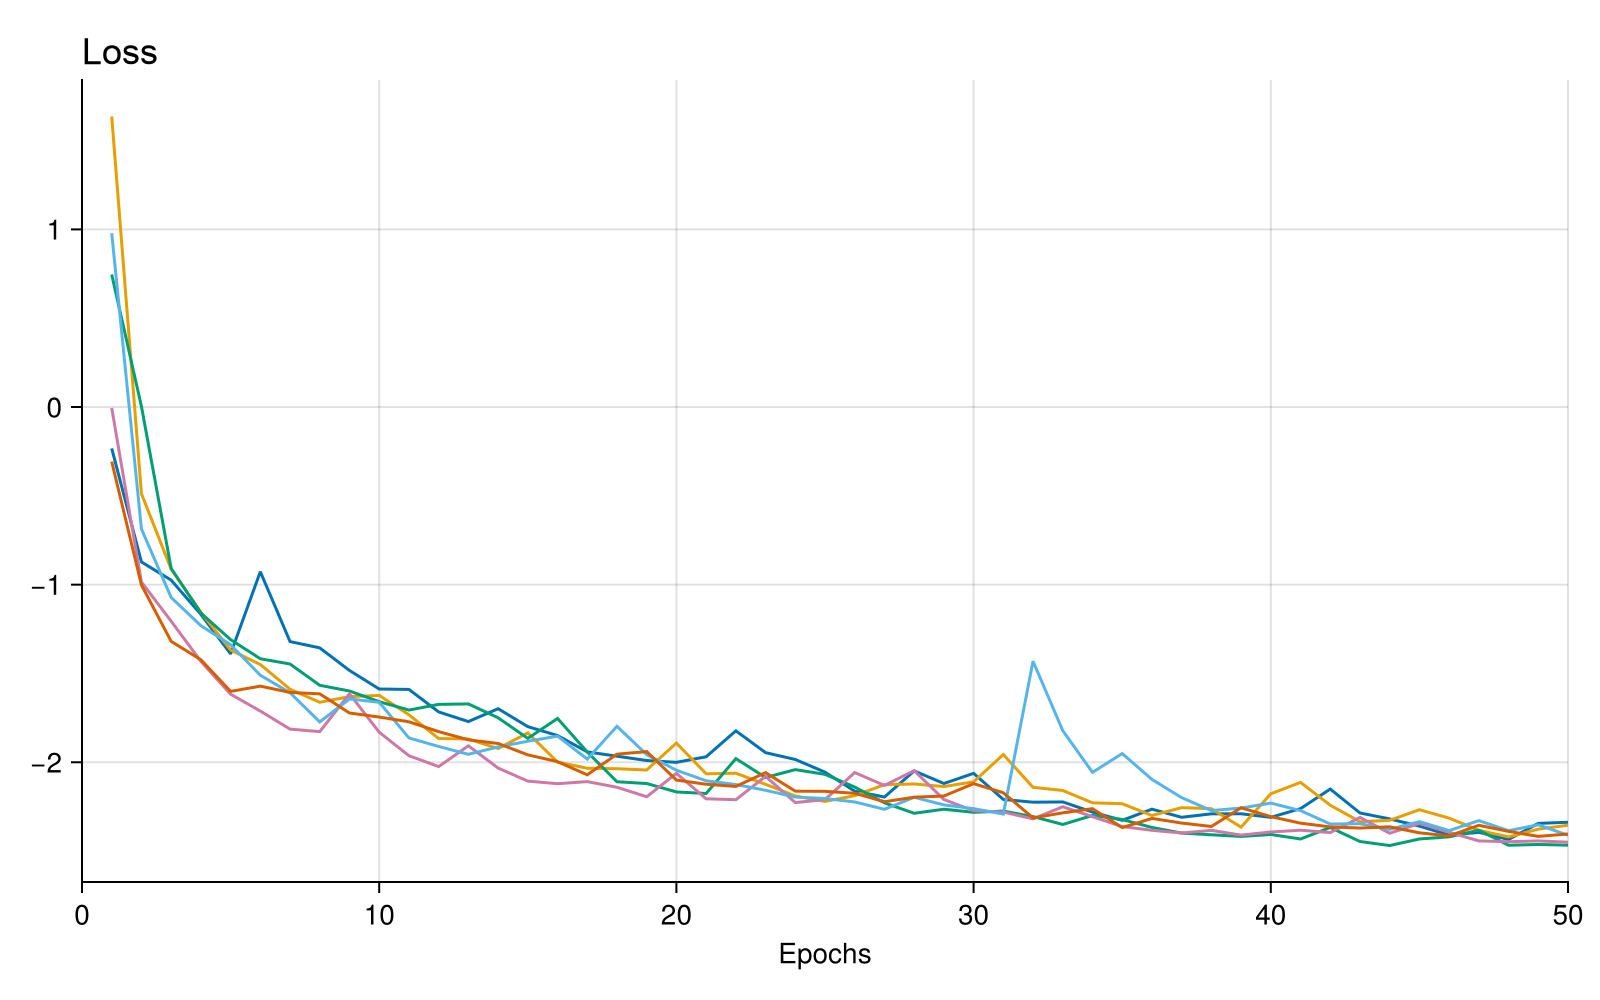

CairoMakie.Screen{IMAGE}


In [20]:
fig = Figure(size = (800, 500))
ax = Axis(
    fig[1, 1],
    xlabel = "Epochs",
    title = "Loss",
    titlealign = :left,
    titlefont = "Arial",
    titlesize = 18,
)
xlims!(ax, (0, length(loss)))

for bestfile in bestfilelist
    bestfileparam = replace(bestfile, ".nc" => "_params.nc")
    ds = NCDataset(joinpath(outputdir, bestfileparam))
    loss = ds["losses"][:]
    close(ds)
    lines!(ax, 1:length(loss), loss[1:end])
end

hidespines!(ax, :t, :r) # only top and right
figname = "loss_$(varname)_best.png"
# save(joinpath(figdir, figname), fig)
display(fig)

## Prepare plots
### Load bathymetry and mask

In [21]:
bathyfile = joinpath(auxdatadir, "gebco_30sec_16.nc")
CopepodsNN.download_check(bathyfile, CopepodsNN.covariable_urls["gebco_30sec_16"])
_, _, mask = DIVAnd.load_mask(bathyfile, true, longrid, latgrid, 0.0);

[ Info: File ../data/aux_data/gebco_30sec_16.nc already downloaded


In [22]:
date2plot = Date(2008, 5, 1)
timeindex = findfirst(
    (Dates.month.(fielddates_monthly) .== Dates.month(date2plot)) .&
    (Dates.year.(fielddates_monthly) .== Dates.year(date2plot)),
)

605

## Comparison of results

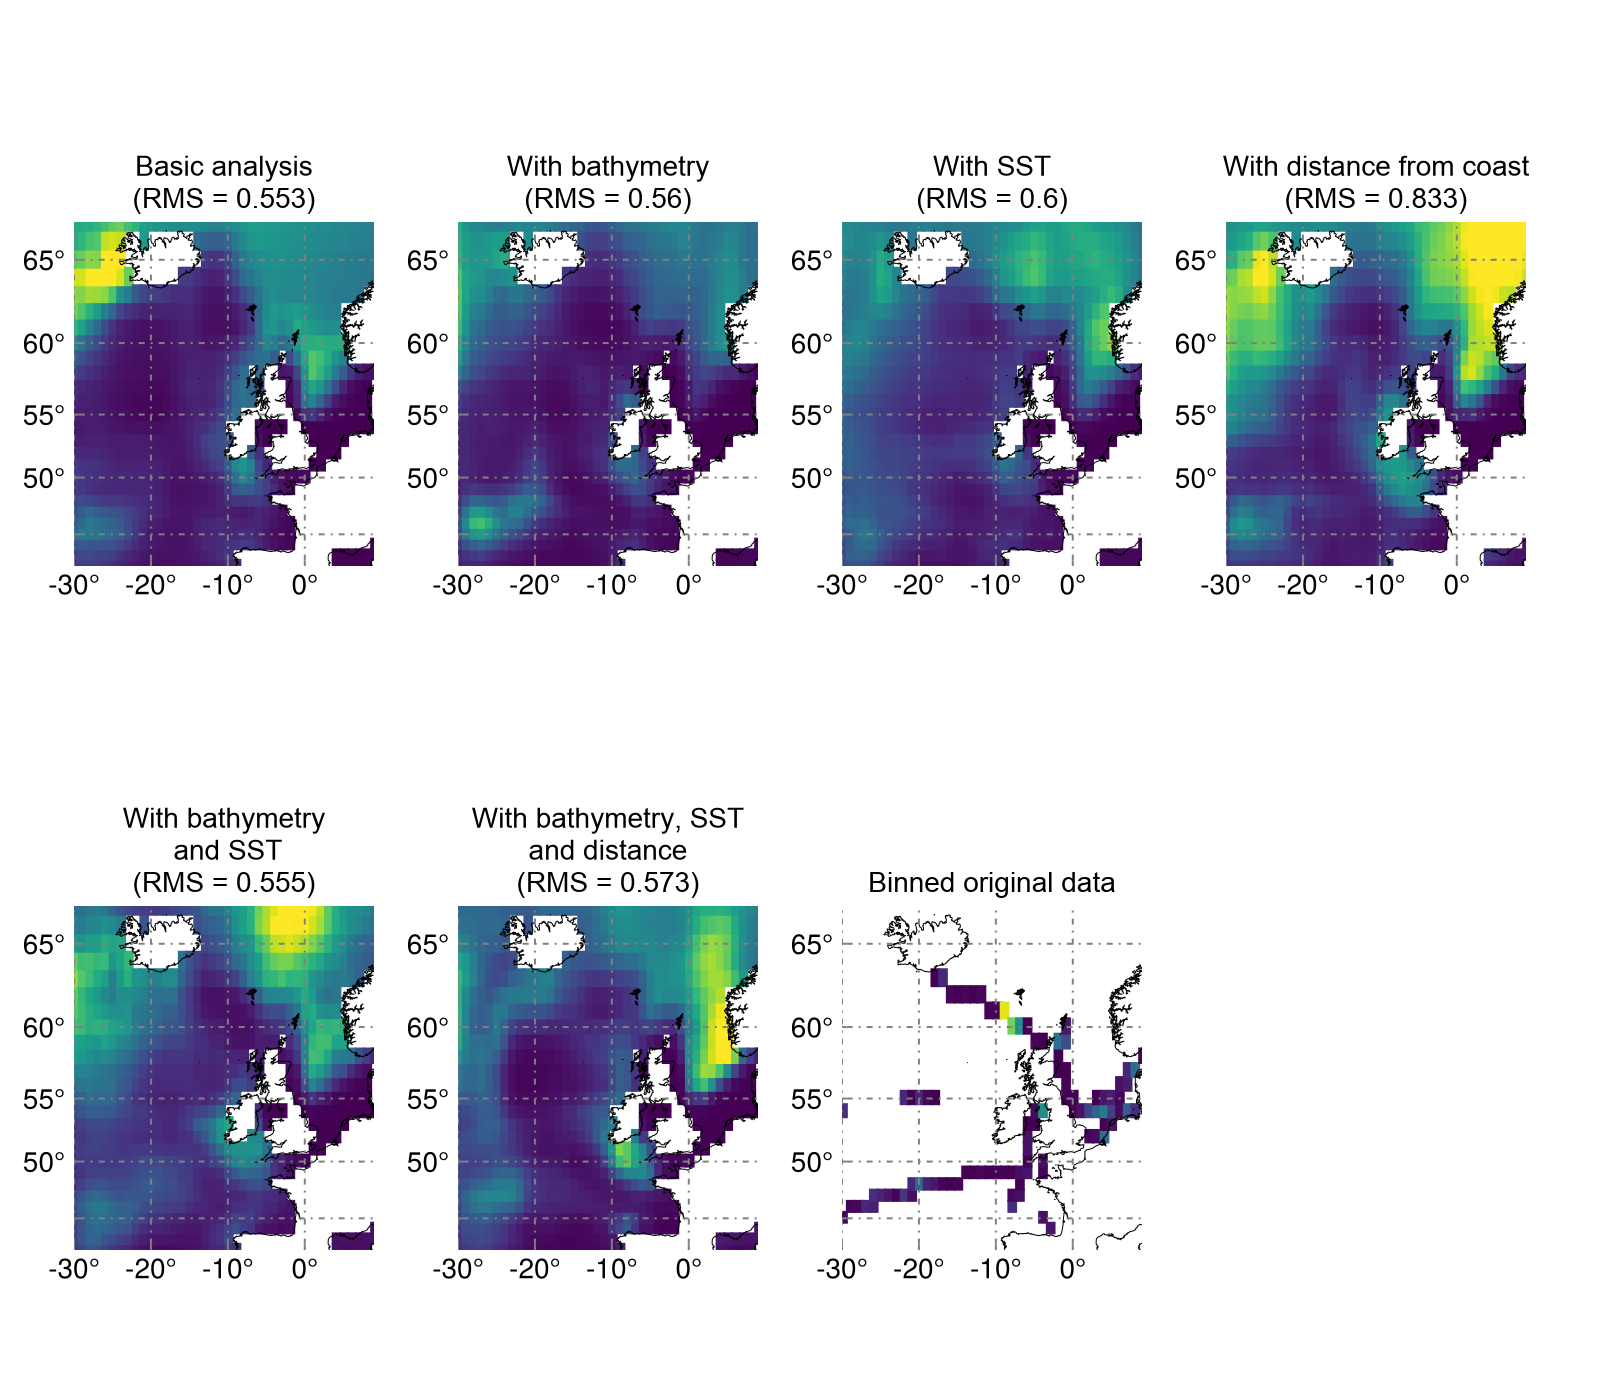

CairoMakie.Screen{IMAGE}


In [31]:
fig = Figure(size = (800, 700))

field2plot, RMS =
    CopepodsNN.get_field(joinpath(outputdir, bestfilelist[1]), varname, timeindex)

ga1 = CopepodsNNplots.create_geoaxis(
    fig,
    ii = 1,
    jj = 1,
    title = "Basic analysis\n(RMS = $(RMS))",
    domain = domain,
)

field2plot[.!mask] .= NaN
heatmap!(ga1, longrid, latgrid, field2plot, colorrange = (vmin[varname], vmax[varname]))
lines!(ga1, GeoMakie.coastlines(10); color = :black, linewidth = 0.5)

# ---------------

field2plot, RMS =
    CopepodsNN.get_field(joinpath(outputdir, bestfilelist[2]), varname, timeindex)

ga2 = CopepodsNNplots.create_geoaxis(
    fig,
    ii = 1,
    jj = 2,
    title = "With bathymetry\n(RMS = $(RMS))",
    domain = domain,
)

field2plot[.!mask] .= NaN
heatmap!(ga2, longrid, latgrid, field2plot, colorrange = (vmin[varname], vmax[varname]))
lines!(ga2, GeoMakie.coastlines(10); color = :black, linewidth = 0.5)

# ---------------

field2plot, RMS =
    CopepodsNN.get_field(joinpath(outputdir, bestfilelist[3]), varname, timeindex)

ga3 = CopepodsNNplots.create_geoaxis(
    fig,
    ii = 1,
    jj = 3,
    title = "With SST\n(RMS = $(RMS))",
    domain = domain,
)

field2plot[.!mask] .= NaN
heatmap!(ga3, longrid, latgrid, field2plot, colorrange = (vmin[varname], vmax[varname]))
lines!(ga3, GeoMakie.coastlines(10); color = :black, linewidth = 0.5)

# ---------------

field2plot, RMS =
    CopepodsNN.get_field(joinpath(outputdir, bestfilelist[4]), varname, timeindex)


ga3b = CopepodsNNplots.create_geoaxis(
    fig,
    ii = 1,
    jj = 4,
    title = "With distance from coast\n(RMS = $(RMS))",
    domain = domain,
)

field2plot[.!mask] .= NaN
heatmap!(ga3b, longrid, latgrid, field2plot, colorrange = (vmin[varname], vmax[varname]))
lines!(ga3b, GeoMakie.coastlines(10); color = :black, linewidth = 0.5)

# ---------------
field2plot, RMS =
    CopepodsNN.get_field(joinpath(outputdir, bestfilelist[5]), varname, timeindex)


ga4 = CopepodsNNplots.create_geoaxis(
    fig,
    ii = 2,
    jj = 1,
    title = "With bathymetry\n and SST\n(RMS = $(RMS))",
    domain = domain,
)

field2plot[.!mask] .= NaN
heatmap!(ga4, longrid, latgrid, field2plot, colorrange = (vmin[varname], vmax[varname]))
lines!(ga4, GeoMakie.coastlines(10); color = :black, linewidth = 0.5)

# ---------------
field2plot, RMS =
    CopepodsNN.get_field(joinpath(outputdir, bestfilelist[6]), varname, timeindex)


ga5 = CopepodsNNplots.create_geoaxis(
    fig,
    ii = 2,
    jj = 2,
    title = "With bathymetry, SST\nand distance\n(RMS = $(RMS))",
    domain = domain,
)

field2plot[.!mask] .= NaN
heatmap!(ga5, longrid, latgrid, field2plot, colorrange = (vmin[varname], vmax[varname]))
lines!(ga5, GeoMakie.coastlines(10); color = :black, linewidth = 0.5)

# ---------------

ga6 = CopepodsNNplots.create_geoaxis(
    fig,
    ii = 2,
    jj = 3,
    title = "Binned original data",
    domain = domain,
)
binneddatafile = joinpath(datadir, "$(varname)_DINCAE_datanum_mean2.nc")
ds = NCDataset(binneddatafile, "r")
field2plot = ds["data_nmean"][:, :, timeindex]
close(ds)

field2plot[.!mask] .= NaN
heatmap!(ga6, longrid, latgrid, field2plot, colorrange = (vmin[varname], vmax[varname]))
lines!(ga6, GeoMakie.coastlines(10); color = :black, linewidth = 0.5)

colgap!(fig.layout, 0)
rowgap!(fig.layout, 0)
resize_to_layout!(fig)
figname = "comparison_$(varname)_best.png"
save(joinpath(figdir, figname), fig)
display(fig)

## Analysis the best file

In [33]:
ds = NCDataset(joinpath(outputdir, bestfilelist[2]), "r")
bestfield = ds[varname][:, :, :]
close(ds)

closed Dataset

### Time series 

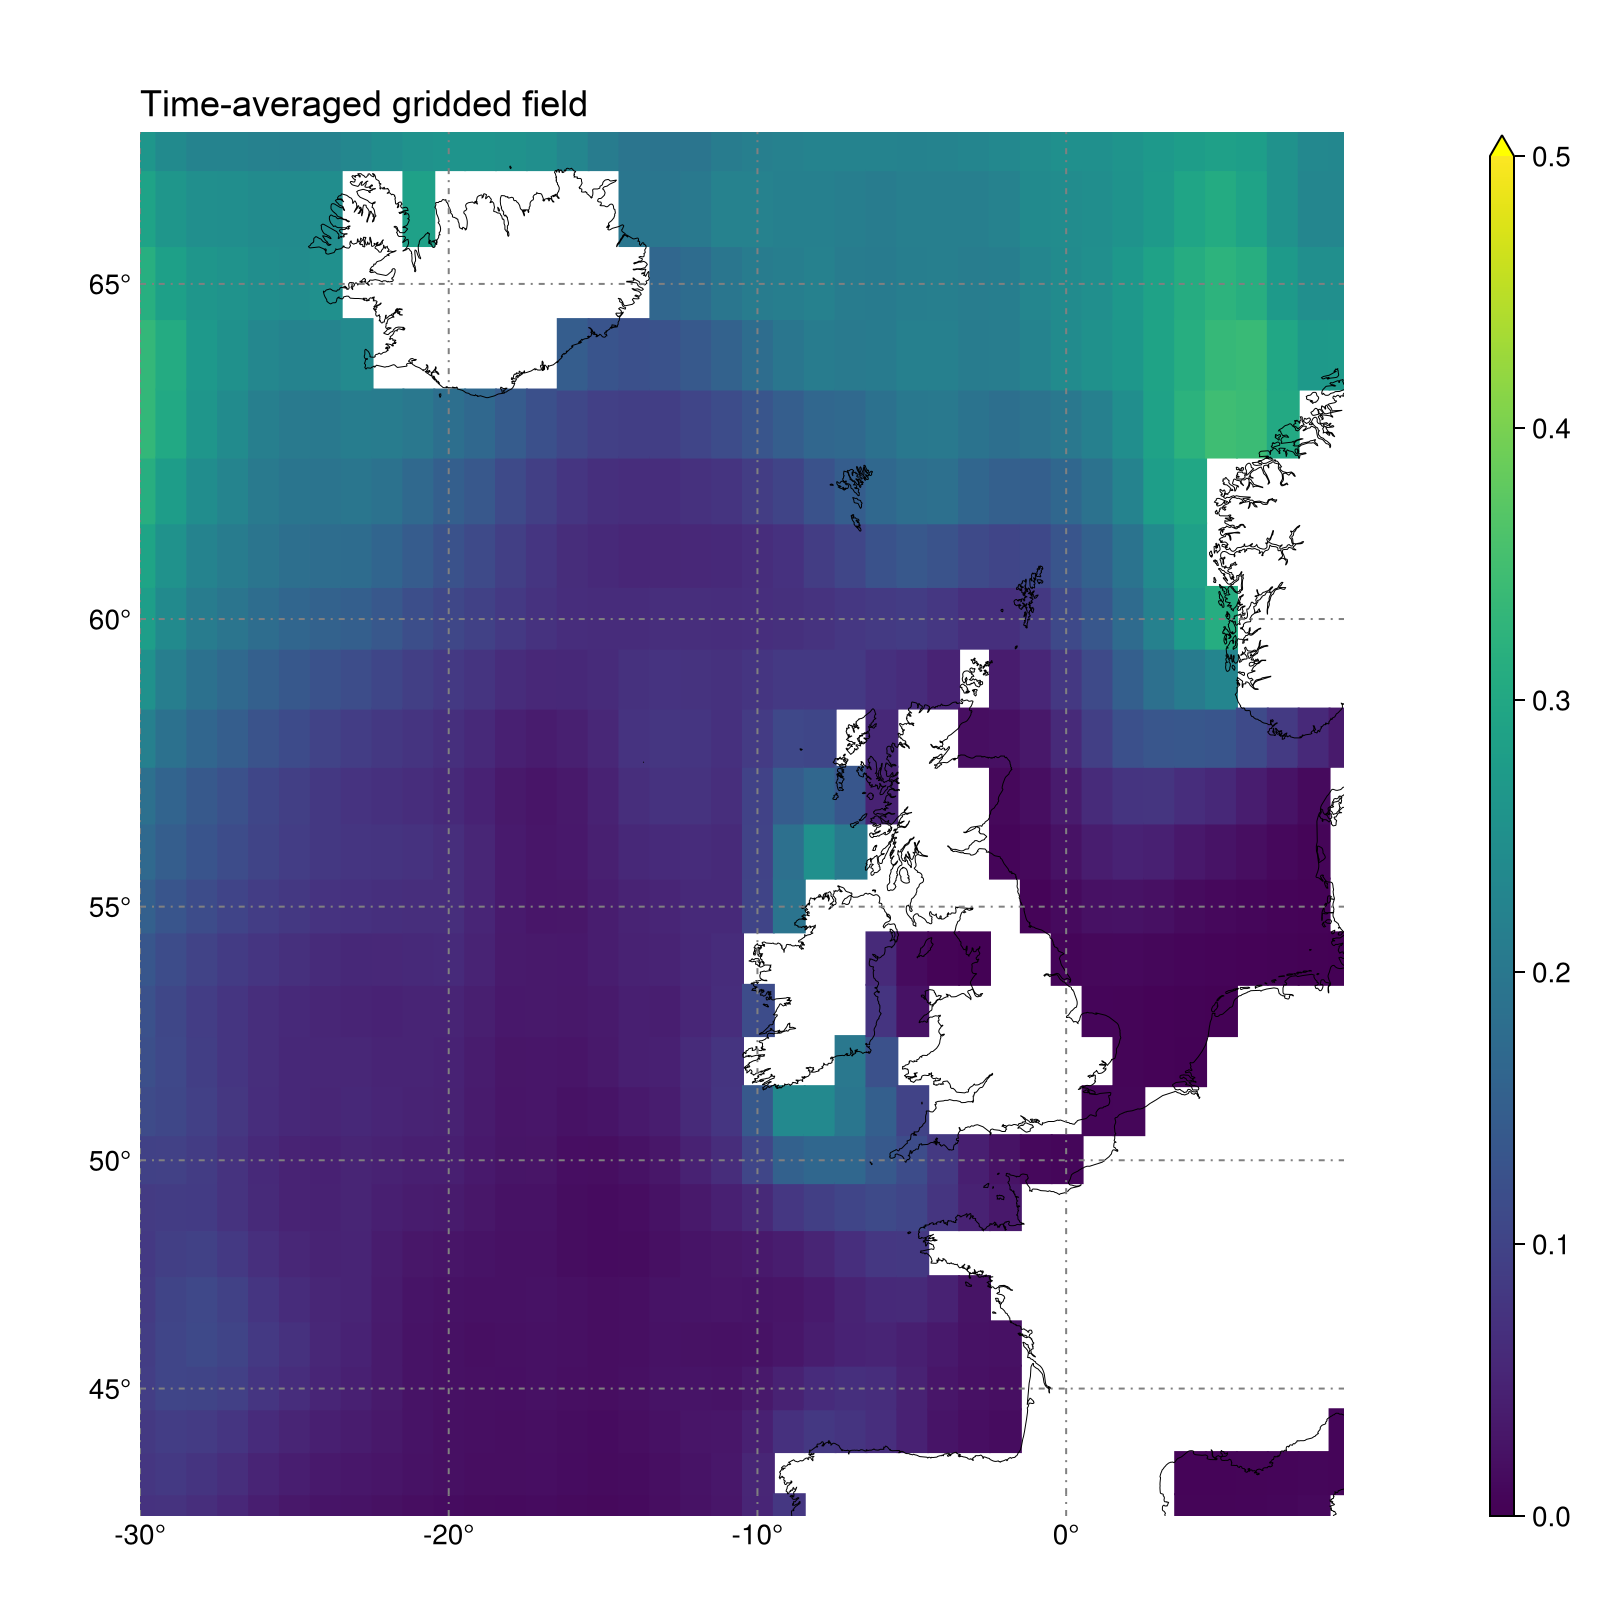

CairoMakie.Screen{IMAGE}


In [39]:
bestfieldavg = dropdims(mean(bestfield, dims = 3), dims = 3);
fig = Figure(size = (800, 800))

ga1 = CopepodsNNplots.create_geoaxis(
    fig,
    ii = 1,
    jj = 1,
    title = "Time-averaged gridded field",
    domain = domain,
)

ga1.titlealign = :left
ga1.titlesize = 18

bestfieldavg[.!mask] .= NaN
hm = heatmap!(
    ga1,
    longrid,
    latgrid,
    bestfieldavg,
    colorrange = (0, vmax[varname]),
    highclip = :yellow,
)
lines!(ga1, GeoMakie.coastlines(10); color = :black, linewidth = 0.5)
Colorbar(fig[1, 2], hm)
figname = "time_averaged_$(varname)_best_00.png"
save(joinpath(figdir, figname), fig)
display(fig)

### Monthly fields

In [40]:
for mmm = 1:12
    gooddates = findall(Dates.month.(fielddates_monthly) .== mmm)
    bestfieldavg = dropdims(mean(bestfield[:, :, gooddates], dims = 3), dims = 3)

    fig = Figure(size = (800, 800))

    ga1 = CopepodsNNplots.create_geoaxis(
        fig,
        ii = 1,
        jj = 1,
        title = "Time-averaged gridded field ($(Dates.monthname(mmm)))",
        domain = domain,
    )

    ga1.titlealign = :left
    ga1.titlesize = 18

    bestfieldavg[.!mask] .= NaN
    hm = heatmap!(
        ga1,
        longrid,
        latgrid,
        bestfieldavg,
        colorrange = (0, 1.5 * vmax[varname]),
        highclip = :yellow,
    )
    lines!(ga1, GeoMakie.coastlines(10); color = :black, linewidth = 0.5)
    Colorbar(fig[1, 2], hm)
    figname = "time_averaged_$(varname)_best_$(lpad(string(mmm), 2, '0')).png"
    save(joinpath(figdir, figname), fig)
end

## Spatial average

In [41]:
goodlon = findall((longrid .>= domain[1]) .& (longrid .< domain[2]));
goodlat = findall((latgrid .>= domain[3]) .& (latgrid .< domain[4]));
bestfieldtimevg = zeros(Float64, length(fielddates_monthly));
obstimeavg = zeros(Float64, length(fielddates_monthly));
yearsobs1 = Dates.year.(obsdates)
monthobs1 = Dates.month.(obsdates)
for (ttt, thedates) in enumerate(fielddates_monthly)
    theyear = Dates.year(thedates)
    themonth = Dates.month(thedates)

    goodtimes = findall((yearsobs1 .== theyear) .& (monthobs1 .== themonth))

    bestfieldtimevg[ttt] = mean(bestfield[goodlon, goodlat, ttt])
    obstimeavg[ttt] = mean(obsvalues[goodtimes])
end

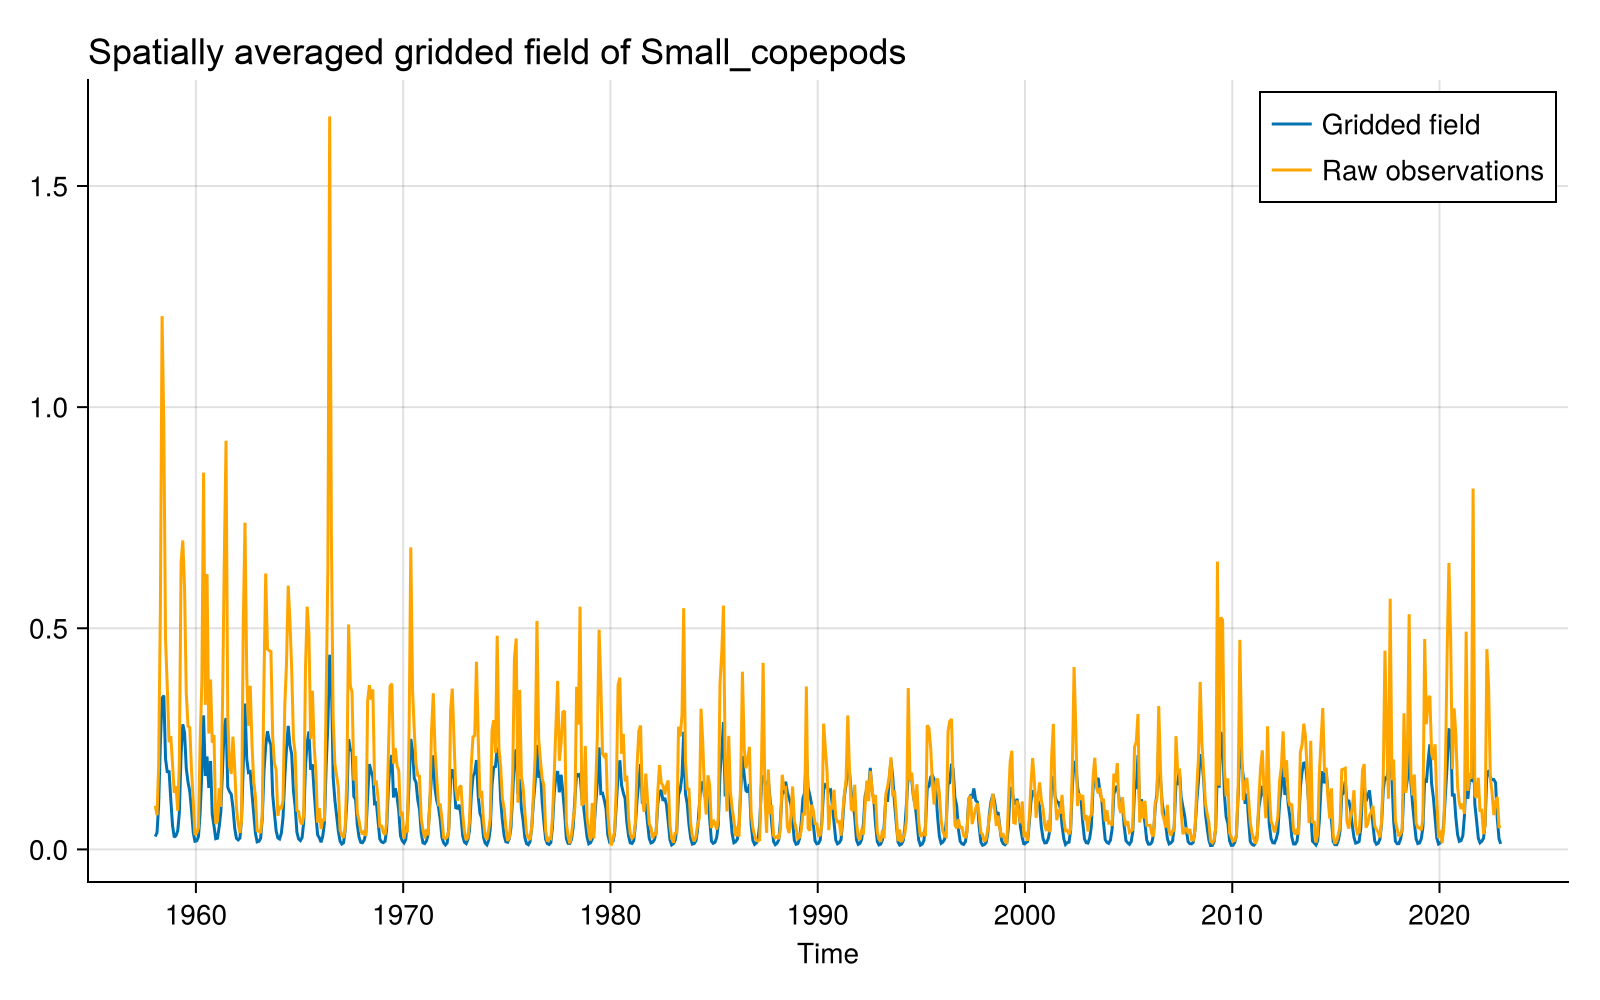

CairoMakie.Screen{IMAGE}


In [42]:
fig = Figure(size = (800, 500))
ax = Axis(
    fig[1, 1],
    xlabel = "Time",
    title = "Spatially averaged gridded field of $(varname)",
    titlefont = "Arial",
    titlealign = :left,
    titlesize = 18,
)
lines!(ax, fielddates_monthly, bestfieldtimevg, label = "Gridded field")
lines!(ax, fielddates_monthly, obstimeavg, color = :orange, label = "Raw observations")

ax.xticks = ([Date(yyyy, 1, 1) for yyyy = 1960:10:2020], string.(1960:10:2020))
axislegend(ax)
hidespines!(ax, :t, :r) # only top and right
figname = "spatial_avareged_$(varname)_best.png"
save(joinpath(figdir, figname), fig)
display(fig)

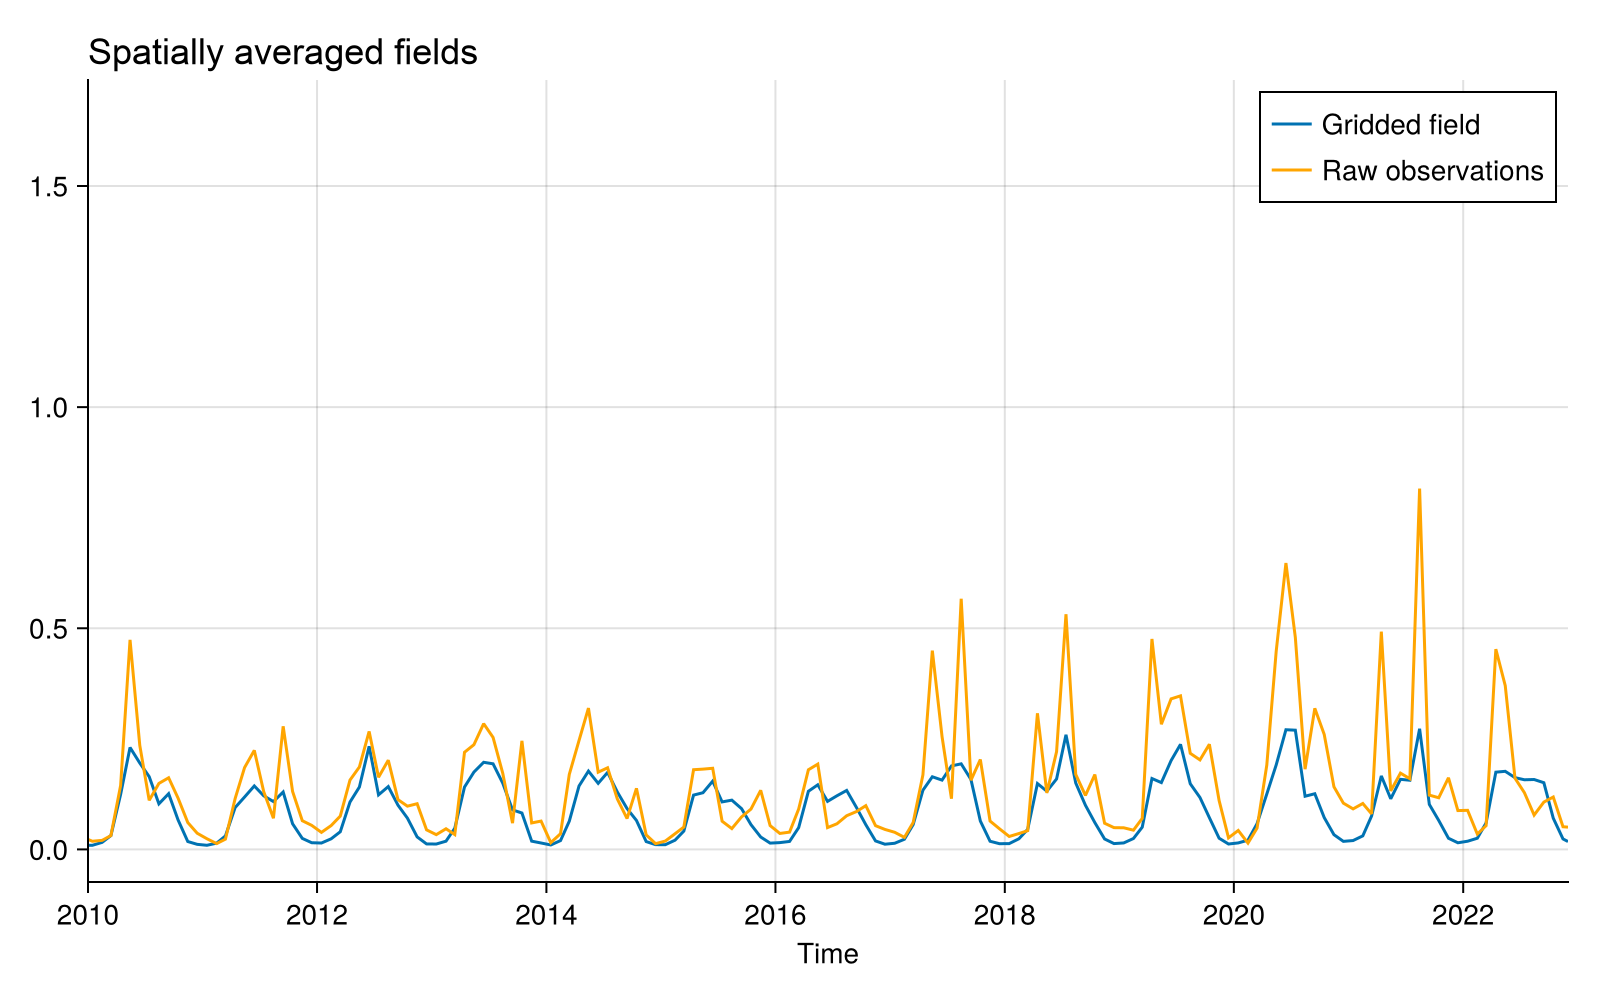

CairoMakie.Screen{IMAGE}


In [43]:
fig = Figure(size = (800, 500))
ax = Axis(
    fig[1, 1],
    xlabel = "Time",
    title = "Spatially averaged fields",
    titlealign = :left,
    titlefont = "Arial",
    titlesize = 18,
)
low_limit = Makie.date_to_number(DateTime, DateTime(2010, 1, 1))
high_limit = Makie.date_to_number(DateTime, DateTime(2022, 12, 1))
xlims!(ax, low_limit, high_limit)
lines!(ax, fielddates_monthly, bestfieldtimevg, label = "Gridded field")
lines!(ax, fielddates_monthly, obstimeavg, color = :orange, label = "Raw observations")

# ax.xticks = ([Date(yyyy, 1, 1) for yyyy = 1960:10:2020], string.(1960:10:2020))
axislegend(ax)
hidespines!(ax, :t, :r) # only top and right
figname = "spatial_avareged_$(varname)_best_2010_2022.png"
save(joinpath(figdir, figname), fig)
display(fig)

## Time average
Warning: only take the central domain (without the extension).

In [44]:
longridcalc = domain[1]:Δlon:domain[2]
latgridcalc = domain[3]:Δlat:domain[4]

42.0:1.0:67.0

In [45]:
nlon = length(longridcalc)
nlat = length(latgridcalc)
nobsgrid = zeros(Float64, nlat, nlon)
meanobsgrid = zeros(Float64, nlat, nlon)
for iii = 1:nlon-1
    goodlon = findall((obslon .>= longridcalc[iii]) .& (obslon .< longridcalc[iii+1]))
    for jjj = 1:nlat-1
        goodlat = findall((obslat .>= latgridcalc[jjj]) .& (obslat .< latgridcalc[jjj+1]))
        goodcoords = intersect(goodlon, goodlat)
        nobsgrid[jjj, iii] = length(goodcoords)
        meanobsgrid[jjj, iii] = mean(obsvalues[goodcoords])
    end
end

In [46]:
nobsgrid[nobsgrid.==0.0] .= NaN
fig = Figure(size = (800, 800))

ga1 = CopepodsNNplots.create_geoaxis(
    fig,
    ii = 1,
    jj = 1,
    title = "Number of observations in each grid cell",
    domain = domain,
)

ga1.titlealign = :left
ga1.titlesize = 18

hm = heatmap!(
    ga1,
    longridcalc,
    latgridcalc,
    nobsgrid',
    colorrange = (1, 1000),
    colormap = :Oranges,
    highclip = :black,
)
#scatter!(ga1, lon1, lat1, color = :green, markersize = 2)
ga1.titlealign = :left
ga1.titlesize = 18
Colorbar(fig[1, 2], hm)

lines!(ga1, GeoMakie.coastlines(10); color = :black, linewidth = 0.5)
figname = "numobs_grid_$(varname).png"
save(joinpath(figdir, figname), fig)

In [47]:
fig = Figure(size = (800, 800))

ga1 = CopepodsNNplots.create_geoaxis(
    fig,
    ii = 1,
    jj = 1,
    title = "Mean value in each grid cell",
    domain = domain,
)

ga1.titlealign = :left
ga1.titlesize = 18

hm = heatmap!(
    ga1,
    longridcalc,
    latgridcalc,
    meanobsgrid',
    colorrange = (0, vmax[varname]),
    highclip = :yellow,
)
#scatter!(ga1, lon1, lat1, color = :green, markersize = 2)
ga1.titlealign = :left
ga1.titlesize = 18
Colorbar(fig[1, 2], hm)

lines!(ga1, GeoMakie.coastlines(10); color = :black, linewidth = 0.5)
figname = "time_averaged_$(varname)_rawdata_00.png"
save(joinpath(figdir, figname), fig)

In [48]:
for mmm = 1:12
    meanobsgrid = zeros(Float64, nlat, nlon)
    gooddates = findall(Dates.month.(obsdates) .== mmm)
    for iii = 1:nlon-1
        goodlon = findall((obslon .>= longridcalc[iii]) .& (obslon .< longridcalc[iii+1]))
        for jjj = 1:nlat-1
            goodlat =
                findall((obslat .>= latgridcalc[jjj]) .& (obslat .< latgridcalc[jjj+1]))
            goodcoords = intersect(goodlon, goodlat)
            goodvalues = intersect(goodcoords, gooddates)
            meanobsgrid[jjj, iii] = mean(obsvalues[goodvalues])
        end
    end

    fig = Figure(size = (800, 800))

    ga1 = CopepodsNNplots.create_geoaxis(
        fig,
        ii = 1,
        jj = 1,
        title = "Mean value in each grid cell ($(Dates.monthname(mmm)))",
        domain = domain,
    )

    ga1.titlealign = :left
    ga1.titlesize = 18

    hm = heatmap!(
        ga1,
        longridcalc,
        latgridcalc,
        meanobsgrid',
        colorrange = (0, 1.5 * vmax[varname]),
        highclip = :yellow,
    )
    #scatter!(ga1, lon1, lat1, color = :green, markersize = 2)
    ga1.titlealign = :left
    ga1.titlesize = 18
    Colorbar(fig[1, 2], hm)

    lines!(ga1, GeoMakie.coastlines(10); color = :black, linewidth = 0.5)
    figname = "time_averaged_$(varname)_rawdata_$(lpad(string(mmm), 2, '0')).png"
    save(joinpath(figdir, figname), fig)
end